# Labor 5

A laboron a hatékony csempézés (osztott és konstans memória hasznélata), általános kétdimenziós konvolúciót fogjuk implementálni és kipróbálni.

A konvolúció egy alapvető művelet a képfeldolgozásban, olyan feladatok alapját képezi, mint az éldetektálás, elmosás, élesítés és sok más. Mivel ezek a műveletek pixel szinten gyakran függetlenül végezhetők, kiválóan párhuzamosíthatók GPU-n.

A labor célja egy hatékony konvolúciós kernel megírása, amely kihasználja a CUDA által kínált memórioptimalizálási lehetőségeket:
*   Csempézés (tiling): A kép blokkokra (csempékre) bontása az adat-újrahasznosítás maximalizálása érdekében.
*   Osztott memória (shared memory): A csempék gyors, programozható gyorsítótárba való betöltése a globális memóriaelérések csökkentésére.
*   Konstans memória (constant memory): A konvolúciós maszk hatékony tárolása és elérése.


## A konvolúciós művelet áttekintése

A 2D konvolúció során egy kisebb mátrixot, az úgynevezett **konvolúciós maszkot** (vagy kernelt) csúsztatunk végig a bemeneti képen. Minden pozícióban a maszk alatti képpixelek és a maszkelemek súlyozott összegét számoljuk ki, ez adja a kimeneti kép adott pixelének értékét.

A kép akár több színcsatornás lehet (pl. RGB). A konvolúciót ilyenkor minden csatornára külön-külön el kell végezni.

**Pszeudokód:**

```
maskWidth := 5
maskRadius := maskWidth / 2 // Egész osztás, eredménye 2

// I_float: bemeneti kép (float, 0.0-1.0, height x width x channels, INTERLEAVED: RGBRGB...)
// K: konvolúciós maszk (maskWidth x maskWidth)
// P_float: kimeneti kép (float, 0.0-1.0, height x width x channels, INTERLEAVED: RGBRGB...)

for i from 0 to height-1 do       // Sorok (y)
  for j from 0 to width-1 do    // Oszlopok (x)
    for c from 0 to channels-1 do // Színcsatornák
      accum := 0.0
      for my from -maskRadius to maskRadius do   // Maszk sorai
        for mx from -maskRadius to maskRadius do // Maszk oszlopai
          imageX := j + mx
          imageY := i + my

          // Szegélykezelés: Csak a képen belüli pixeleket vesszük figyelembe
          if imageX >= 0 && imageX < width && imageY >= 0 && imageY < height then
            // Interleaved adatszerkezet feltételezése
            imagePixel := I_float[(imageY * width + imageX) * channels + c]
            maskValue := K[(my + maskRadius) * maskWidth + (mx + maskRadius)]
            accum += imagePixel * maskValue
          end if
        end for
      end for
      // Pixelértékek [0, 1] között, vágás (clamping)
      P_float[(i * width + j) * channels + c] = clamp(accum, 0.0, 1.0)
    end for
  end for
end for

function clamp(value, min_val, max_val)
  return min(max(value, min_val), max_val)
end function
```
A szegélykezelésnél (amikor a maszk "kilóg" a képből) a pszeudokód egyszerűen nem veszi figyelembe a képen kívüli részeket. A kernelünkben ezt nullákkal való feltöltéssel (padding) oldjuk meg az osztott memóriában.

## CUDA memóriahierarchia és optimalizáció

A GPU-k számítási teljesítménye óriási, de ezt csak akkor tudjuk kihasználni, ha az adatokat elég gyorsan tudjuk a feldolgozó egységekhez (Streaming Multiprocessor, SM) juttatni. A CUDA különböző memóriatípusokat kínál, eltérő sebességgel, mérettel és hozzáférési móddal:

*   Globális memória (Global memory): Nagy (több GB), de lassú. Minden szál olvashatja és írhatja.
*   Konstans memória (Constant memory): Kisebb (pl. 64KB), csak olvasható, de gyorsítótárazott. Akkor ideális, ha sok szál ugyanazt az adatot olvassa (pl. konvolúciós maszk).
*   Textúra memória (Texture memory): Csak olvasható, gyorsítótárazott, speciális címzési és szűrési módokkal rendelkezik, ami hasznos lehet képfeldolgozásnál.
*   Osztott memória (Shared memory): Nagyon gyors, programozható gyorsítótár az SM-en belül, egy blokk szálai számára közös. Mérete korlátozott (pl. 48KB/96KB SM-enként). Kulcsfontosságú a csempézéshez.
*   Regiszterek (Registers): A leggyorsabb memória, minden szálnak saját regiszterei vannak.

A célunk a lassú globális memóriaelérések minimalizálása azáltal, hogy az adatokat (vagy azok egy részét) gyorsabb memóriatípusokba töltjük át.

### Konstans memória használata a maszkhoz

A konvolúciós maszk a számítás során nem változik, és minden képpont feldolgozásakor ugyanazt a maszkot használjuk. Ez ideálissá teszi a konstans memóriában való tárolásra. Ha a maszk mutatója `M` az eszközön, a kernel definíciójakor használhatjuk a `const float * __restrict__ M` dekorációt:

```cpp
__global__ void convolutionKernel(float *I, const float *__restrict__ M, /* ... */)
```
*   `const`: Tájékoztatja a fordítót, hogy a `M` által mutatott adat nem fog megváltozni a kernel futása során.
*   `__restrict__`: Ígéret a fordítónak, hogy a kernel futása során csak az `M` mutatón keresztül érjük el az adott memóriaterületet.

Ez a módszer általában előnyösebb, mint a régebbi `__constant__` globális változó használata.

### Osztott memória és csempézés (tiling)

A konvolúció során egy adott bemeneti pixelhez többször is hozzáférünk. A **csempézés (tiling)** technika lényege, hogy a bemeneti képet kisebb, átlapolódó blokkokra (csempékre) osztjuk. Egy-egy ilyen csempét betöltünk a sokkal gyorsabb **osztott memóriába (shared memory)**. Egy CUDA blokk szálai ezután közösen dolgoznak ezen a csempén.

Amikor egy csempét betöltünk, figyelembe kell venni a **peremzónát (halo)** is. Mivel pl. egy 5x5-ös maszk túlnyúlhat az aktuálisan számított pixelen, a csempe szélein lévő pixelekhez szükségünk van a szomszédos adatokra is. Tehát az osztott memóriába egy kicsit nagyobb területet kell betölteni. Ha egy blokk egy `OUTPUT_TILE_WIDTH` x `OUTPUT_TILE_WIDTH` méretű kimeneti csempét számol, és a maszk sugara `maskRadius`, akkor az osztott memóriába egy `(OUTPUT_TILE_WIDTH + 2 * maskRadius)` x `(OUTPUT_TILE_WIDTH + 2 * maskRadius)` méretű bemeneti területet kell betölteni. Ezt `INPUT_TILE_WIDTH = OUTPUT_TILE_WIDTH + MASK_WIDTH - 1` formában is írhatjuk.

A szálak szinkronizációja (`__syncthreads()`) kritikus.

# Feladat

Implementáljuk a kurzuson is ismertetett általános kétdimenziós konvolúciót CUDA-ban.

Próbáljuk ki a következő konvolúciót maszkokat:

1.  **Élkiemelés ([Laplace-szerű](https://www.tutorialspoint.com/dip/laplacian_operator.htm)):**
    ```cpp
    // float mask_raw[] = {
    //     0,  0, -1,  0,  0,
    //     0, -1, -2, -1,  0,
    //    -1, -2, 16, -2, -1, // Középen 16, összege 0
    //     0, -1, -2, -1,  0,
    //     0,  0, -1,  0,  0
    // };
    // // Ehhez a maszkhoz nem feltétlenül kell normalizálás, az eredményt clamp-elni kell.
    // // Az értékek összege 0, ami tipikus az élkiemelőknél.
    ```

2.  **Élesítés ([Unsharp Masking](https://en.wikipedia.org/wiki/Unsharp_masking) jellegű):**
    ```cpp
    // float mask_raw[] = {
    //    -1, -1, -1, -1, -1,
    //    -1, -1, -1, -1, -1,
    //    -1, -1, 25, -1, -1, // Összege 1 (25 pozitív, 24 negatív)
    //    -1, -1, -1, -1, -1,
    //    -1, -1, -1, -1, -1
    // };
    // //  Nem kell normalizálni, ha az összege 1.
    ```


https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

In [3]:
import requests

# URL for stb_image.h
url_stb_image = "https://raw.githubusercontent.com/nothings/stb/master/stb_image.h"

# Download stb_image.h
response_image = requests.get(url_stb_image)
if response_image.status_code == 200:
    with open("stb_image.h", "wb") as f:
        f.write(response_image.content)
    print("stb_image.h downloaded successfully!")
else:
    print(f"Failed to download stb_image.h. Status code: {response_image.status_code}")


stb_image.h downloaded successfully!


In [4]:
import requests

# URL for stb_image_write.h
url_stb_image_write = "https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h"

# Download stb_image_write.h
response_image_write = requests.get(url_stb_image_write)
if response_image_write.status_code == 200:
    with open("stb_image_write.h", "wb") as f:
        f.write(response_image_write.content)
    print("stb_image_write.h downloaded successfully!")
else:
    print(f"Failed to download stb_image_write.h. Status code: {response_image_write.status_code}")


stb_image_write.h downloaded successfully!


### 1. feladat

In [18]:
!wget -O input.png https://colab.research.google.com/img/colab_favicon_256px.png

--2026-01-01 11:14:32--  https://colab.research.google.com/img/colab_favicon_256px.png
Resolving colab.research.google.com (colab.research.google.com)... 142.250.4.138, 142.250.4.101, 142.250.4.113, ...
Connecting to colab.research.google.com (colab.research.google.com)|142.250.4.138|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4534 (4.4K) [image/png]
Saving to: ‘input.png’

input.png           100%[===================>]   4.43K  --.-KB/s    in 0s      

2026-01-01 11:14:32 (41.2 MB/s) - ‘input.png’ saved [4534/4534]



In [19]:
%%writefile laplace.cu
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>

#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"

#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

// ================== PARAMÉTEREK ==================
#define CHANNELS 3
#define MASK_WIDTH 5
#define MASK_RADIUS 2

#define OUTPUT_TILE_WIDTH 16
#define INPUT_TILE_WIDTH (OUTPUT_TILE_WIDTH + MASK_WIDTH - 1)

// ================== KONSTANS MEMÓRIA ==================
__constant__ float d_mask[MASK_WIDTH * MASK_WIDTH];

// ================== SEGÉDFÜGGVÉNY ==================
__host__ __device__ float clamp(float value, float min_val, float max_val) {
    return fminf(fmaxf(value, min_val), max_val);
}

// ================== KERNEL ==================
__global__ void convolutionKernel(
    const float* __restrict__ input,
    float* output,
    int width,
    int height
) {
    __shared__ float tile[INPUT_TILE_WIDTH][INPUT_TILE_WIDTH][CHANNELS];

    int tx = threadIdx.x;
    int ty = threadIdx.y;

    int row_o = blockIdx.y * OUTPUT_TILE_WIDTH + ty;
    int col_o = blockIdx.x * OUTPUT_TILE_WIDTH + tx;

    int row_i = row_o - MASK_RADIUS;
    int col_i = col_o - MASK_RADIUS;

    // ====== Betöltés shared memóriába (halo-val) ======
    for (int c = 0; c < CHANNELS; c++) {
        if (row_i >= 0 && row_i < height &&
            col_i >= 0 && col_i < width &&
            tx < INPUT_TILE_WIDTH &&
            ty < INPUT_TILE_WIDTH) {

            tile[ty][tx][c] =
                input[(row_i * width + col_i) * CHANNELS + c];
        } else {
            tile[ty][tx][c] = 0.0f;
        }
    }

    __syncthreads();

    // ====== Konvolúció ======
    if (ty < OUTPUT_TILE_WIDTH &&
        tx < OUTPUT_TILE_WIDTH &&
        row_o < height &&
        col_o < width) {

        for (int c = 0; c < CHANNELS; c++) {
            float acc = 0.0f;

            for (int my = 0; my < MASK_WIDTH; my++) {
                for (int mx = 0; mx < MASK_WIDTH; mx++) {
                    float imageVal = tile[ty + my][tx + mx][c];
                    float maskVal = d_mask[my * MASK_WIDTH + mx];
                    acc += imageVal * maskVal;
                }
            }

            acc = clamp(acc, 0.0f, 1.0f);

            output[(row_o * width + col_o) * CHANNELS + c] = acc;
        }
    }
}

// ================== MAIN ==================
int main() {
    int width, height, channels;

    unsigned char* h_img =
        stbi_load("input.png", &width, &height, &channels, CHANNELS);

    if (!h_img) {
        printf("Nem sikerült betölteni a képet!\n");
        return 1;
    }

    printf("Kép betöltve: %dx%d\n", width, height);

    int pixels = width * height * CHANNELS;

    float* h_input  = (float*)malloc(pixels * sizeof(float));
    float* h_output = (float*)malloc(pixels * sizeof(float));

    // uint8 → float [0,1]
    for (int i = 0; i < pixels; i++) {
        h_input[i] = h_img[i] / 255.0f;
    }

    // ====== Maszk (élkiemelés) ======
    float h_mask[MASK_WIDTH * MASK_WIDTH] = {
         0,  0, -1,  0,  0,
         0, -1, -2, -1,  0,
        -1, -2, 16, -2, -1,
         0, -1, -2, -1,  0,
         0,  0, -1,  0,  0
    };

    cudaMemcpyToSymbol(d_mask, h_mask,
        MASK_WIDTH * MASK_WIDTH * sizeof(float));

    float *d_input, *d_output;
    cudaMalloc(&d_input,  pixels * sizeof(float));
    cudaMalloc(&d_output, pixels * sizeof(float));

    cudaMemcpy(d_input, h_input,
        pixels * sizeof(float), cudaMemcpyHostToDevice);

    dim3 block(INPUT_TILE_WIDTH, INPUT_TILE_WIDTH);
    dim3 grid(
        (width  + OUTPUT_TILE_WIDTH - 1) / OUTPUT_TILE_WIDTH,
        (height + OUTPUT_TILE_WIDTH - 1) / OUTPUT_TILE_WIDTH
    );

    printf("Kernel indítás...\n");

    convolutionKernel<<<grid, block>>>(
        d_input, d_output, width, height);

    cudaDeviceSynchronize();

    cudaMemcpy(h_output, d_output,
        pixels * sizeof(float), cudaMemcpyDeviceToHost);

    // float → uint8
    for (int i = 0; i < pixels; i++) {
        h_img[i] = (unsigned char)(clamp(h_output[i], 0.0f, 1.0f) * 255.0f);
    }

    stbi_write_png("output.png", width, height,
        CHANNELS, h_img, width * CHANNELS);

    printf("Kimenet elmentve: output.png\n");

    // ====== Takarítás ======
    stbi_image_free(h_img);
    free(h_input);
    free(h_output);
    cudaFree(d_input);
    cudaFree(d_output);

    return 0;
}


Overwriting laplace.cu


In [20]:
!nvcc -arch=sm_75 laplace.cu -lpthread -lX11 -ljpeg -diag-suppress 550

In [24]:
!ls

a.out	   laplace.cu  sample_data  stb_image_write.h
input.png  output.png  stb_image.h


In [22]:
!./a.out

Kép betöltve: 260x260
Kernel indítás...
Kimenet elmentve: output.png


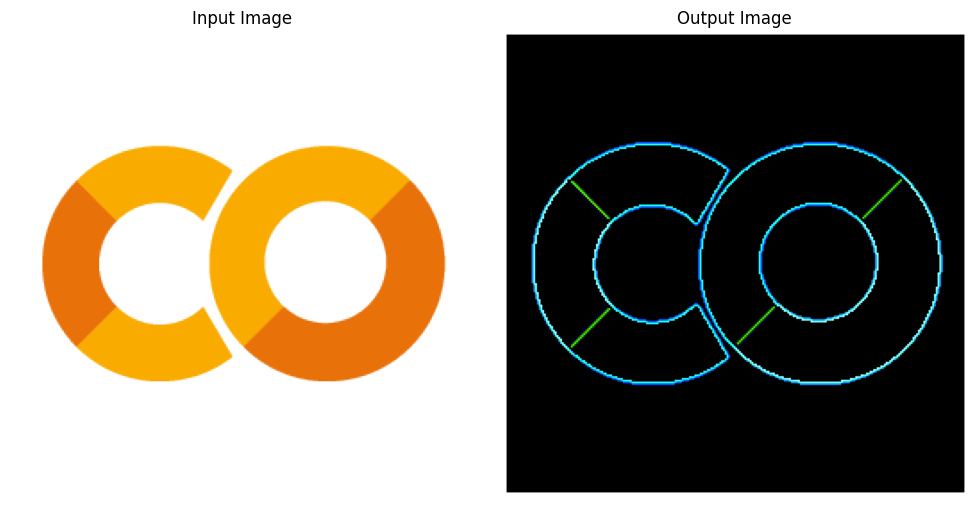

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the images
input_img = Image.open('input.png')
output_img = Image.open('output.png')

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the input image
axes[0].imshow(input_img)
axes[0].set_title('Input Image')
axes[0].axis('off') # Hide axes ticks

# Display the output image
axes[1].imshow(output_img)
axes[1].set_title('Output Image')
axes[1].axis('off') # Hide axes ticks

plt.tight_layout()
plt.show()


### 2. feladat